# First a1000 Success Rate

Plots only the first `a1000` `eval/success_rate` run from the latest W&B export.

In [13]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

In [16]:
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / 'problem' / 'Data' / 'SACBC_Eval',
    Path('problem') / 'Data' / 'SACBC_Eval',
]

csv_files = []
for d in candidate_dirs:
    files = sorted(d.glob('wandb_export_*.csv'))
    if files:
        csv_files = files
        break

if not csv_files:
    raise FileNotFoundError('No wandb_export_*.csv found in expected locations.')

csv_path = csv_files[-1]
print(f'Using CSV: {csv_path.resolve()}')
df = pd.read_csv(csv_path)

Using CSV: C:\Users\jiand\unsynced\RL_Project\final_project_offline_online\problem\Data\SACBC_Eval\wandb_export_2026-04-13T17_21_09.603-07_00.csv


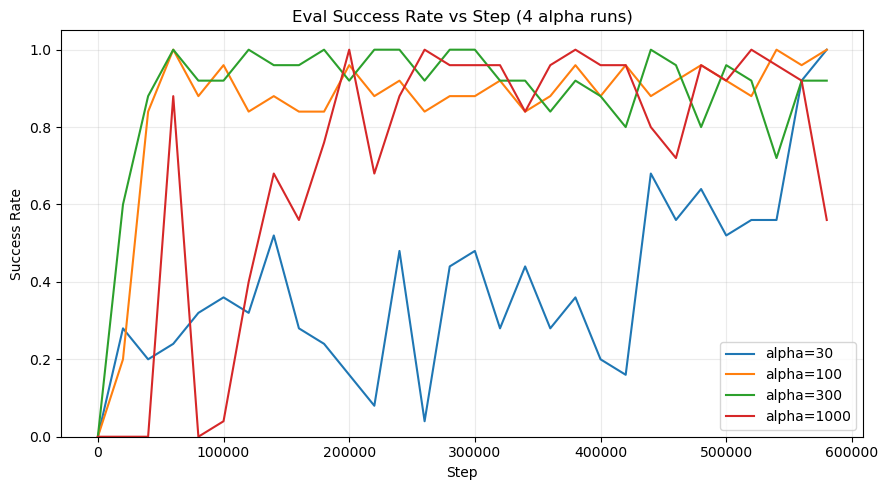

In [18]:
step_col = "Step"
base_suffix = " - eval/success_rate"
base_cols = [c for c in df.columns if c.endswith(base_suffix)]

target_alphas = [30, 100, 300, 1000]
selected = {}

for alpha in target_alphas:
    pattern = rf"_a{alpha}(?:\.0+)?_"
    matches = [c for c in base_cols if re.search(pattern, c)]
    if matches:
        selected[alpha] = matches[0]  # first run for this alpha

missing = [a for a in target_alphas if a not in selected]
if missing:
    raise ValueError(f"Missing eval/success_rate columns for alphas: {missing}")

x = pd.to_numeric(df[step_col], errors="coerce")

plt.figure(figsize=(9, 5))
for alpha in target_alphas:
    col = selected[alpha]
    y = pd.to_numeric(df[col], errors="coerce")
    plt.plot(x, y, label=f"alpha={alpha}")

plt.title("Eval Success Rate vs Step (4 alpha runs)")
plt.xlabel("Step")
plt.ylabel("Success Rate")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()
